# 09 · Wine Quality — Interpretability (gain vs permutation vs SHAP, dependence, local)

## Part 9 — Interpretability

A model that predicts well but can't be explained is a hard sell to a winemaker. This part opens the
box on the LightGBM quality model with three lenses:

- **Importance — three ways**: gain, permutation, and SHAP. They *disagree*, and *why* they disagree
  is itself a lesson about correlated features.
- **SHAP global (beeswarm)**: every wine, every feature, showing direction and magnitude.
- **Dependence**: *how* a feature moves quality across its range (not just "how much").
- **Local**: why *this one wine* got the score it did.

We interpret the **regression** model (Part 6) so SHAP values are in *quality points* — e.g. "high
alcohol adds +0.3 to predicted quality" — which is far more legible than log-odds.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from lightgbm import LGBMRegressor
from sklearn.inspection import permutation_importance
import shap
raw = data.clean(); Xtr, Xte, ytr, yte = M.split(raw)
reg = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=0, verbose=-1, n_jobs=-1).fit(Xtr, ytr)
explainer = shap.TreeExplainer(reg); sv = explainer.shap_values(Xte)
print("test QWK %.3f | SHAP base value (mean prediction) %.2f" % (M.qwk(yte, reg.predict(Xte)), explainer.expected_value))

setup ok | numpy 2.1.3 | pandas 2.3.3


test QWK 0.525 | SHAP base value (mean prediction) 5.80


### 1. Three importances that *disagree* — and why

- **Gain**: total loss reduction from a feature's splits. Fast, but **biased when features are
  correlated** — it scatters credit among look-alikes.
- **Permutation**: shuffle a feature, measure how much MAE worsens. Model-agnostic, honest about
  *predictive* value — but splits credit between correlated features too.
- **SHAP**: game-theoretic, *consistent* attribution that sums to each prediction.

Watch **`alcohol_density`**: gain ranks it nearly **last**, yet permutation and SHAP rank it **first**.
Because it's derived from alcohol and density, the tree spreads its splits across the trio and *gain*
under-credits the engineered feature — while SHAP/permutation see its true contribution. **Moral: don't
rank features by gain alone when they're correlated.**

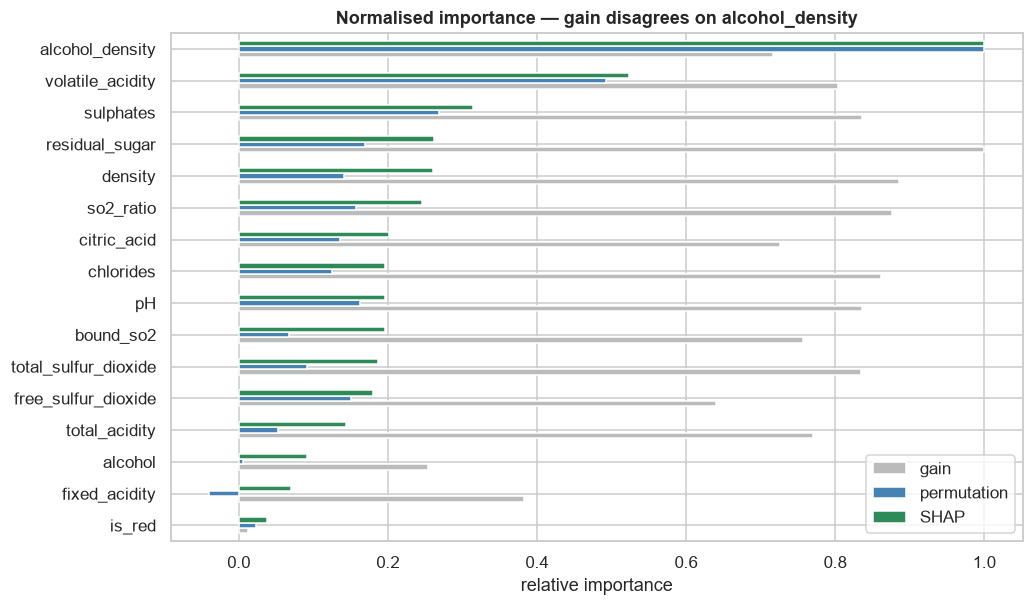

alcohol_density ranks -> gain #12, permutation #1, SHAP #1 (of 16)


In [2]:
gain = pd.Series(reg.feature_importances_, index=Xtr.columns)
perm = pd.Series(permutation_importance(reg, Xte, yte, n_repeats=5, random_state=0,
                                        scoring="neg_mean_absolute_error").importances_mean, index=Xte.columns)
shap_imp = pd.Series(np.abs(sv).mean(0), index=Xte.columns)
comp = pd.DataFrame({"gain": gain, "permutation": perm, "SHAP": shap_imp})
norm = comp / comp.max()                       # scale each method to [0,1] to compare shapes
norm = norm.loc[shap_imp.sort_values().index]
fig, ax = plt.subplots(figsize=(10, 6)); norm.plot.barh(ax=ax, color=["#bbb","steelblue","seagreen"])
ax.set_title("Normalised importance — gain disagrees on alcohol_density"); ax.set_xlabel("relative importance")
eda.savefig(fig, "p9_importance_compare.png"); plt.show()
print("alcohol_density ranks -> gain #%d, permutation #%d, SHAP #%d (of %d)" %
      (gain.rank(ascending=False)["alcohol_density"], perm.rank(ascending=False)["alcohol_density"],
       shap_imp.rank(ascending=False)["alcohol_density"], len(gain)))

### 2. SHAP beeswarm — the global picture

Each dot is one wine; position = that feature's SHAP push on its predicted quality; colour = the
feature's value (red high, blue low). Read it directly: **high `alcohol_density` (red) sits on the
right** (pushes quality *up*); **high `volatile_acidity` (red) sits on the left** (pushes quality
*down*). The whole EDA story, confirmed inside the model and quantified in quality points.

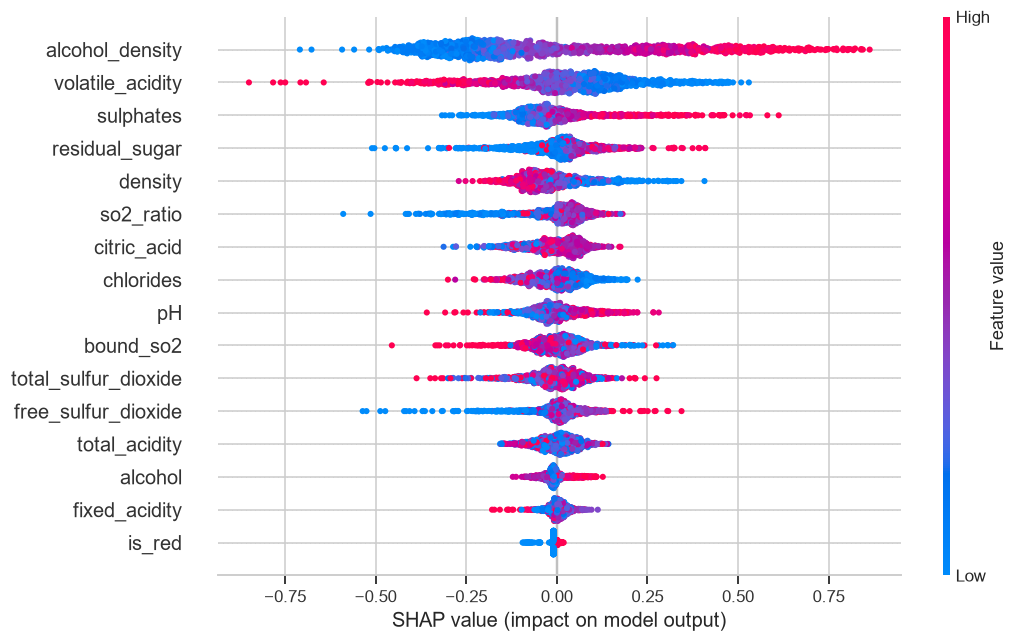

In [3]:
shap.summary_plot(sv, Xte, show=False, plot_size=(10, 6))
eda.savefig(plt.gcf(), "p9_beeswarm.png"); plt.show()

### 3. Dependence — *how*, not just *how much*

A dependence plot traces a feature's SHAP value across its range. **`alcohol_density`** rises smoothly
(more "normalised strength" → higher quality, with diminishing returns at the top), while
**`volatile_acidity`** falls then plateaus (a little is fine; past a threshold the vinegar taint
dominates). The colour reveals interactions — the effect shifts with a second feature.

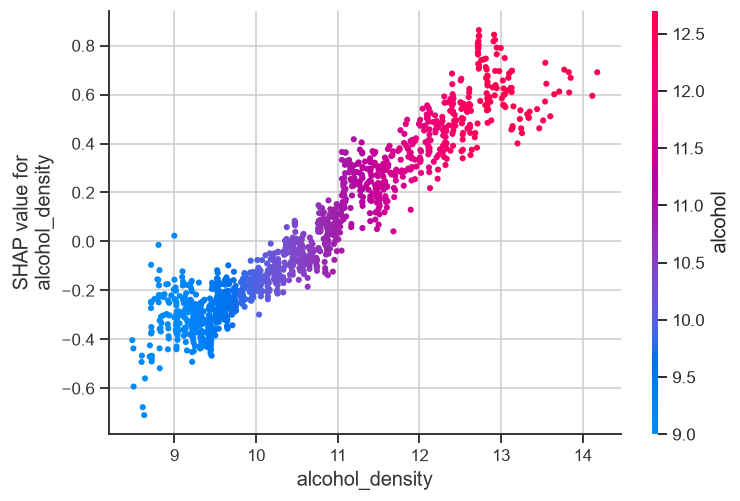

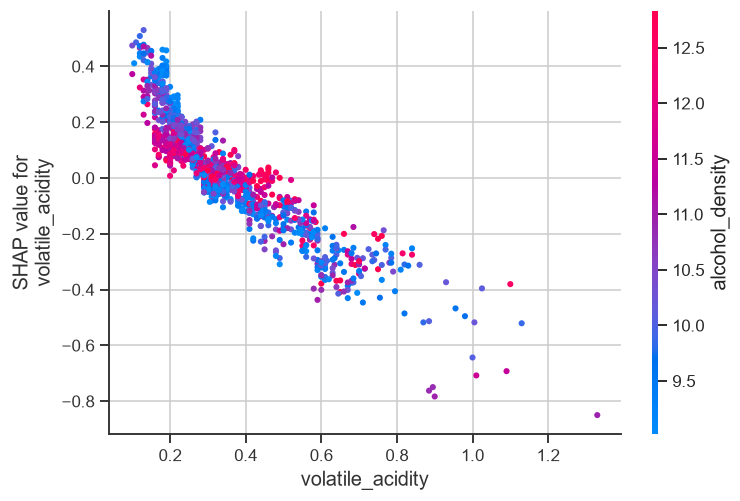

In [4]:
for feat, fname in [("alcohol_density", "p9_dep_alcohol.png"), ("volatile_acidity", "p9_dep_volatile.png")]:
    shap.dependence_plot(feat, sv, Xte, show=False)
    eda.savefig(plt.gcf(), fname); plt.show()

### 4. Local — why *this* wine?

Global importance is the average story; a winemaker asks about **one bottle**. A SHAP waterfall starts
at the base value (mean prediction ≈ 5.8) and adds each feature's contribution to reach this wine's
score — a complete, additive, per-wine explanation.

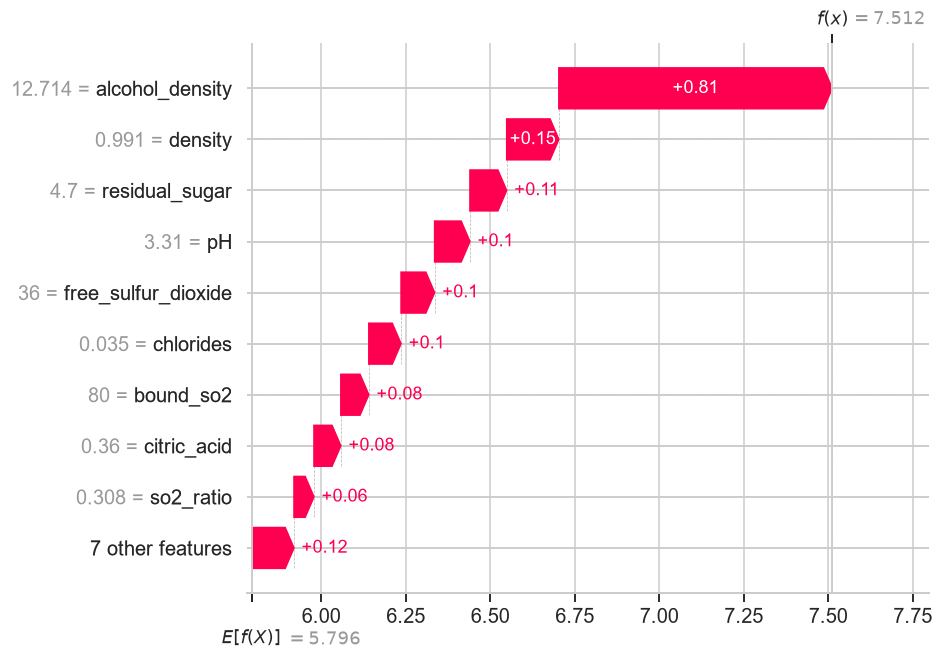

wine #1118: predicted 7.51 (true 6) — top push: alcohol_density


In [5]:
i = int(np.argmax(reg.predict(Xte)))    # explain the highest-predicted wine
ex = shap.Explanation(values=sv[i], base_values=explainer.expected_value, data=Xte.iloc[i], feature_names=list(Xte.columns))
shap.plots.waterfall(ex, max_display=10, show=False)
eda.savefig(plt.gcf(), "p9_waterfall.png"); plt.show()
print("wine #%d: predicted %.2f (true %d) — top push: %s" %
      (i, reg.predict(Xte)[i], yte.iloc[i], Xte.columns[np.argmax(np.abs(sv[i]))]))

### 5. Caveats — interpret responsibly

- SHAP attributions are **associational, not causal**: "high alcohol *predicts* higher quality" ≠
  "adding alcohol *makes* a wine better" (alcohol co-varies with ripeness, technique, …).
- With **correlated features** (our chemistry), credit-splitting is unavoidable — engineered ratios
  like `alcohol_density` can steal attribution from their parents.
- These explain the *model*, which is only as trustworthy as its data (taster bias, the duplicate
  rows, the rare-grade gaps).

### Takeaways

- **Importance method matters**: gain mis-ranks correlated features (alcohol_density last vs SHAP
  first). Prefer **SHAP / permutation**; use gain only as a rough guide.
- The model's drivers are **alcohol/alcohol-density (+), volatile acidity (−), sulphates (+)** — the
  EDA's signals, now quantified in quality points and validated globally *and* locally.
- Dependence plots show the *shape* (alcohol's diminishing returns; volatile acidity's threshold) —
  richer than a single correlation.
- Explanations are **associational**; don't read them as winemaking advice.

**Next — Part 10 (Capstone):** a contrast that ties the practice together — predict **red vs white**
from chemistry (near-perfect, unlike quality) — plus a synthesis of everything Parts 0–9 taught.